In [2]:
import sys
import os

# Get the absolute path to the src folder (parent of current file)
notebook_dir = os.path.dirname(os.path.abspath(""))  # current dir is src/glyco
src_path = os.path.abspath(os.path.join(notebook_dir, "."))  # go up to src

# Add src to sys.path
if src_path not in sys.path:
    sys.path.insert(0, src_path)

%load_ext autoreload
%autoreload 2
# Now import the glyco module
import glyco as gl

In [3]:
d =gl.read_csv(file_path='../../examples/data/out_glucose_sample.csv', delimiter=',')

/Users/a961747/restingit/datamesh/selfgit/glyco/src/glyco/glucose.py:548: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[glbl] = df[glbl].fillna(method="ffill").fillna(method="bfill")


In [4]:
d_ =gl.read_csv(file_path='../../examples/data/out_glucose_sample.csv', delimiter=',', mask_private_info=True)

/Users/a961747/restingit/datamesh/selfgit/glyco/src/glyco/glucose.py:548: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[glbl] = df[glbl].fillna(method="ffill").fillna(method="bfill")


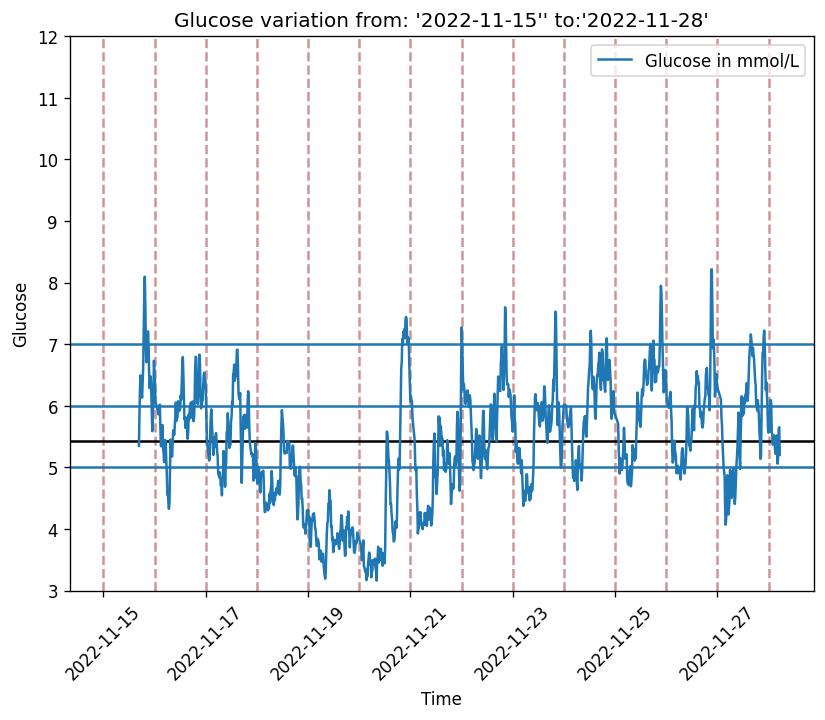

In [5]:
gl.init_plot()
gl.plot_glucose(d, from_time='2022-11-01')
gl.end_plot()

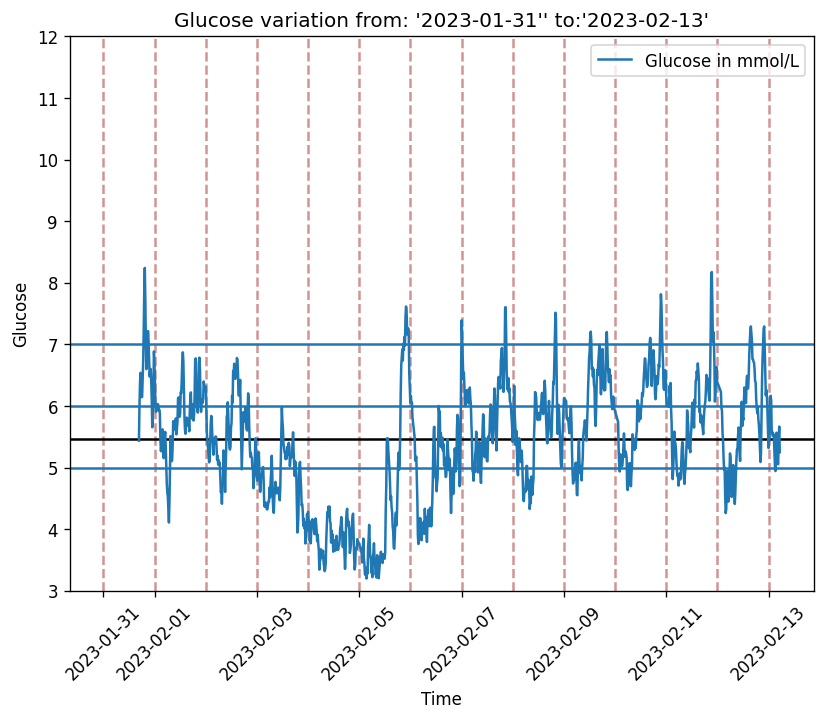

In [6]:
gl.init_plot()
gl.plot_glucose(d_, from_time='2023-01-31')
gl.end_plot()

In [40]:
m_ = gl.auto_recognise_meals(d_)
m = gl.auto_recognise_meals(d)

In [41]:
m.session_id.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39])

In [9]:
m_.session_id.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44])

In [10]:
d_['Notes'].unique()

array(['9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0'],
      dtype=object)

In [42]:
d_['Notes'] = d_['Notes'].astype(str)

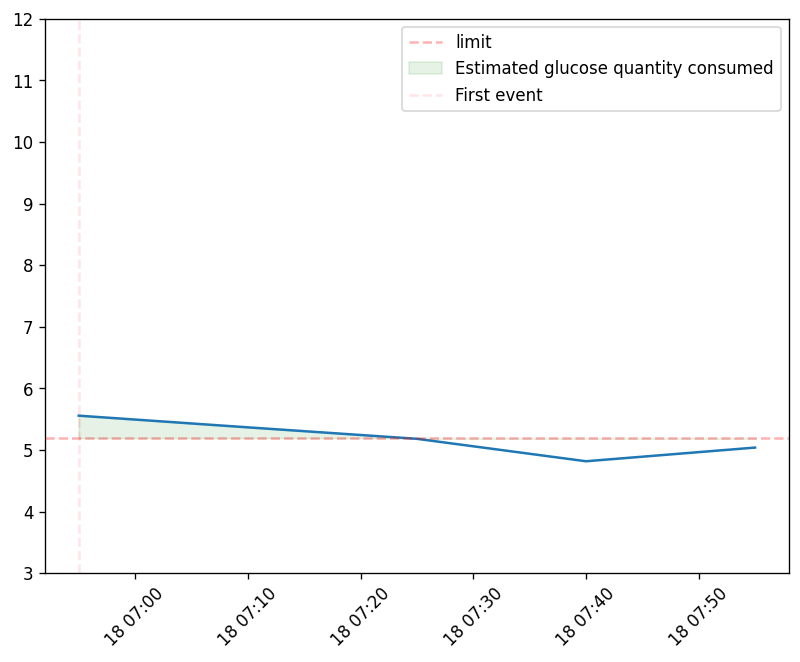

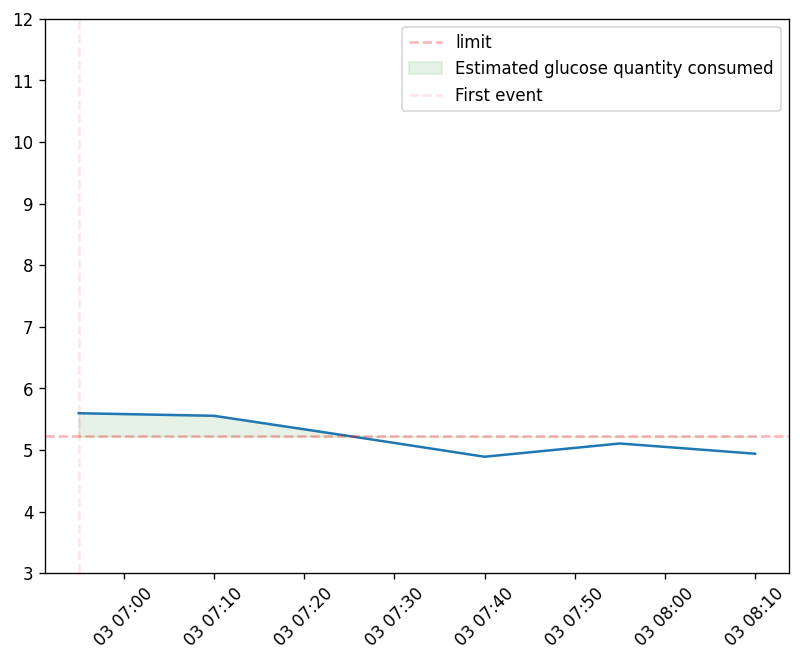

In [12]:
gl.init_plot()
gl.plot_session_response(d, m, session_id=5, use_notes_as_title=False)
gl.end_plot()
gl.init_plot()
gl.plot_session_response(d_, m_, session_id=5, use_notes_as_title=False)
gl.end_plot()

In [13]:
m_[m_['session_id']==5]

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
tsp,,,,,,,,,,,,
2023-01-03 06:55:00,5.595737,2023-01-03 06:55:00,13500.0,900.0,True,False,2023-01-03 06:55:00,2023-01-03 07:10:00,5,2023-01-03 06:55:00,2023-01-03 08:10:00,4500.0
2023-01-03 07:10:00,5.553784,2023-01-03 07:10:00,900.0,2453400.0,False,True,2023-01-03 06:55:00,2023-01-03 07:10:00,5,2023-01-03 06:55:00,2023-01-03 08:10:00,4500.0


In [14]:
d[['glucose', 'tsp']].head()

,glucose,tsp
idx,,
2022-10-16 22:20:00,6.134984,2022-10-16 22:20:00
2022-10-16 22:35:00,6.134984,2022-10-16 22:35:00
2022-10-16 22:49:00,6.134984,2022-10-16 22:49:00
2022-10-16 23:04:00,6.622583,2022-10-16 23:04:00
2022-10-16 23:20:00,6.607900,2022-10-16 23:20:00


In [44]:
d_[['glucose', 'tsp']].head()

,glucose,tsp
idx,,
2023-01-01 22:20:00,6.137022,2023-01-01 22:20:00
2023-01-01 22:35:00,6.137022,2023-01-01 22:35:00
2023-01-01 22:49:00,6.137022,2023-01-01 22:49:00
2023-01-01 23:04:00,6.657060,2023-01-01 23:04:00
2023-01-01 23:20:00,6.540390,2023-01-01 23:20:00


In [45]:
r = d.copy()
r['time'] = r['tsp']
r.drop('tsp')
gl.read_df(r[['glucose', 'tsp']], glucose_col='glucose', timestamp_col='tsp')

KeyError: "['tsp'] not found in axis"

In [16]:
d.columns

Index(['Device', 'Device Timestamp', 'Record Type', 'Historic Glucose mmol/L',
       'Scan Glucose mmol/L', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Carbohydrates (servings)',
       'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin Value (units)',
       'Notes', 'Strip Glucose mmol/L', 'Ketone mmol/L',
       'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Serial Number', 'tsp', 'date',
       'date_str', 'hour', 'weekday_number', 'weekday_name', 'is_weekend',
       'shifted_tsp', 'shifted_date', 'shifted_date_str', 'shifted_hour',
       'shifted_weekday_number', 'shifted_weekday_name', 'shifted_is_weekend',
       'glucose', 'dg', 'dt', 'dg_dt', 'auc_mean', 'auc_lim', 'auc_min'],
      dtype='object')

In [17]:
gl.get_stats(d, stats_cols=['glucose', 'auc_mean'], percentiles=[.75, .8, .9, .99])

,glucose,auc_mean
count,1300.000000,1299.000000
mean,5.404475,363.751654
std,0.955238,526.180232
min,3.162189,0.000000
50%,5.433483,25.821259
75%,6.084305,620.206538
80%,6.233691,756.004560
90%,6.597362,1090.469006
99%,7.469522,1981.856725
max,8.217115,5986.123514


In [18]:
%reload_ext autoreload

In [19]:
m_.columns

Index(['glucose', 'tsp', 'dt_next_event', 'dt_prev_event', 'is_session_first',
       'is_session_last', 'session_first', 'session_last', 'session_id',
       'estimated_start', 'estimated_end', 'estimated_len'],
      dtype='object')

In [20]:
gl.describe_glucose(d)

Glucose Data Summary

• Total number of days in the data: 43
• Starting at: 2022-10-16 22:20
• Ending at: 2022-11-28 05:14

     Glucose Statistics      
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Measure ┃ Value in mmol/L ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Mean    │ 5.40            │
│ Std     │ 0.96            │
│ Min     │ 3.16            │
│ 25%     │ 4.79            │
│ 50%     │ 5.43            │
│ 75%     │ 6.08            │
│ Max     │ 8.22            │
└─────────┴─────────────────┘

Columns in the data: Device, Device Timestamp, Record Type, Historic Glucose mmol/L, Scan Glucose mmol/L, 
Non-numeric Rapid-Acting Insulin, Rapid-Acting Insulin (units), Non-numeric Food, Carbohydrates (grams), 
Carbohydrates (servings), Non-numeric Long-Acting Insulin, Long-Acting Insulin Value (units), Notes, Strip Glucose 
mmol/L, Ketone mmol/L, Meal Insulin (units), Correction Insulin (units), User Change Insulin (units), Serial 
Number, tsp, date, date_str, hour, weekday_number, weekday_name, is_weekend, shifted_tsp, shifted_date, 
shifted_date_str, shifted_hour, shifted_weekday_number, shifted_weekday_name, shifted_is_weekend, glucose, dg, dt, 
dg_dt, auc_mean, auc_lim, auc_min

First rows in the data:
                                     tsp   glucose
idx                                              
2022-10-16 22:20:00 2022-10-16 22:20:00  6.134984
2022-10-16 22:35:00 2022-10-16 22:35:00  6.134984
2022-10-16 22:49:00 2022-10-16 22:49:00  6.134984
2022-10-16 23:04:00 2022-10-16 23:04:00  6.622583
2022-10-16 23:20:00 2022-10-16 23:20:00  6.607900

In [22]:
m_

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
tsp,,,,,,,,,,,,
2023-01-01 22:20:00,6.137022,2023-01-01 22:20:00,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:35:00,6.137022,2023-01-01 22:35:00,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:49:00,6.137022,2023-01-01 22:49:00,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:04:00,6.657060,2023-01-01 23:04:00,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:20:00,6.540390,2023-01-01 23:20:00,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-13 02:13:00,5.548075,2023-02-13 02:13:00,900.0,900.0,False,False,2023-02-12 09:38:00,2023-02-13 02:28:00,42,2023-02-12 09:38:00,2023-02-13 03:28:00,64200.0
2023-02-13 02:28:00,5.496602,2023-02-13 02:28:00,900.0,4500.0,False,True,2023-02-12 09:38:00,2023-02-13 02:28:00,42,2023-02-12 09:38:00,2023-02-13 03:28:00,64200.0
2023-02-13 03:43:00,5.565203,2023-02-13 03:43:00,4500.0,3660.0,True,True,2023-02-13 03:43:00,2023-02-13 03:43:00,43,2023-02-13 03:43:00,2023-02-13 04:44:00,3660.0


In [39]:
m_

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
tsp,,,,,,,,,,,,
2023-01-01 22:20:00,6.137022,2023-01-01 22:20:00,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:35:00,6.137022,2023-01-01 22:35:00,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:49:00,6.137022,2023-01-01 22:49:00,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:04:00,6.657060,2023-01-01 23:04:00,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:20:00,6.540390,2023-01-01 23:20:00,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-13 02:13:00,5.548075,2023-02-13 02:13:00,900.0,900.0,False,False,2023-02-12 09:38:00,2023-02-13 02:28:00,42,2023-02-12 09:38:00,2023-02-13 03:28:00,64200.0
2023-02-13 02:28:00,5.496602,2023-02-13 02:28:00,900.0,4500.0,False,True,2023-02-12 09:38:00,2023-02-13 02:28:00,42,2023-02-12 09:38:00,2023-02-13 03:28:00,64200.0
2023-02-13 03:43:00,5.565203,2023-02-13 03:43:00,4500.0,3660.0,True,True,2023-02-13 03:43:00,2023-02-13 03:43:00,43,2023-02-13 03:43:00,2023-02-13 04:44:00,3660.0


In [36]:
e_=gl.get_event_sessions(m_, d_)

ValueError: 'tsp' is both an index level and a column label, which is ambiguous.

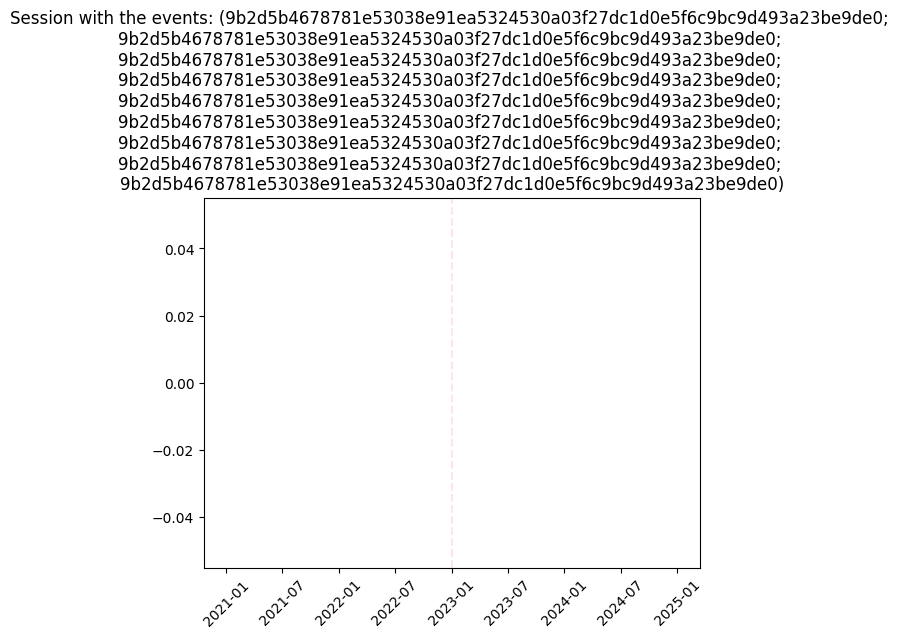

In [30]:
gl.plot_session_response(d, e_, 1, True)

In [35]:
e_.head()

,Device,Device Timestamp,Record Type,Historic Glucose mmol/L,Scan Glucose mmol/L,Non-numeric Rapid-Acting Insulin,Rapid-Acting Insulin (units),Non-numeric Food,Carbohydrates (grams),Carbohydrates (servings),...,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
tsp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 22:20:00,FreeStyle LibreLink,01-01-2023 22:20,0,5.442592,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 22:35:00,FreeStyle LibreLink,01-01-2023 22:35,0,6.570054,NaN,NaN,NaN,NaN,NaN,NaN,...,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 22:49:00,FreeStyle LibreLink,01-01-2023 22:49,0,6.398421,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 23:04:00,FreeStyle LibreLink,01-01-2023 23:04,0,7.002704,NaN,NaN,NaN,NaN,NaN,NaN,...,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 23:20:00,FreeStyle LibreLink,01-01-2023 23:20,0,6.220045,NaN,NaN,NaN,NaN,NaN,NaN,...,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0


In [21]:
gl.describe_meals(esdf=m_, gdf=d)

Meal Events Summary

• Total number of meal sessions: 44
• First recorded meal: 2023-01-01 22:20
• Last recorded meal: 2023-02-13 04:59

• Average estimated meal duration: 278.7 min
• Median estimated meal duration: 90.5 min

             Meal Session Glucose Statistics              
┏━━━━━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Session ID ┃ Start ┃ End ┃ Mean Glucose ┃ Peak Glucose ┃
┡━━━━━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
└────────────┴───────┴─────┴──────────────┴──────────────┘

Columns in meals data: glucose, tsp, dt_next_event, dt_prev_event, is_session_first, is_session_last, 
session_first, session_last, session_id, estimated_start, estimated_end, estimated_len

First rows in the meals DataFrame:
                       glucose                 tsp  dt_next_event  \
tsp                                                                
2023-01-01 22:20:00  6.137022 2023-01-01 22:20:00            NaN   
2023-01-01 22:35:00  6.137022 2023-01-01 22:35:00          900.0   
2023-01-01 22:49:00  6.137022 2023-01-01 22:49:00          840.0   
2023-01-01 23:04:00  6.657060 2023-01-01 23:04:00          900.0   
2023-01-01 23:20:00  6.540390 2023-01-01 23:20:00          960.0   

                     dt_prev_event  is_session_first  is_session_last  \
tsp                                                                     
2023-01-01 22:20:00          900.0              True            False   
2023-01-01 22:35:00          840.0             False            False   
2023-01-01 22:49:00          900.0             False            False   
2023-01-01 23:04:00          960.0             False            False   
2023-01-01 23:20:00          900.0             False            False   

                          session_first        session_last  session_id  \
tsp                                                                       
2023-01-01 22:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 22:35:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 22:49:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 23:04:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 23:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   

                        estimated_start       estimated_end  estimated_len  
tsp                                                                         
2023-01-01 22:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 22:35:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 22:49:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 23:04:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 23:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0